# Parquet exploration (scratch)

This notebook assumes the working directory is the repo root.

Files:
- `data/processed/financials.parquet` (snapshot)
- `data/processed/financials_timeseries.parquet` (timeseries)


In [14]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="darkgrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)


In [15]:
processed_dir = Path("data/processed")
if not processed_dir.exists():
    processed_dir = Path("../../data/processed")

financials_df = pd.read_parquet(processed_dir / "financials.parquet")
timeseries_df = pd.read_parquet(processed_dir / "financials_timeseries.parquet")

display(financials_df.head())
display(timeseries_df.head())


,ticker,as_of_date,company_name,industry,region,Revenues,NetIncomeLoss,Assets,Liabilities,StockholdersEquity,OperatingIncomeLoss,EBIT,EBITDA,CashAndCashEquivalentsAtCarryingValue,LongTermDebt
cik,,,,,,,,,,,,,,,
0000001750,AIR,2025-05-31,AAR CORP,Aircraft & Parts,IL,NaN,1.250000e+07,2.844600e+09,1800000.0,1.211600e+09,NaN,NaN,NaN,9.650000e+07,NaN
0000001800,ABT,2025-12-31,ABBOTT LABORATORIES,Pharmaceutical Preparations,IL,NaN,6.524000e+09,8.671300e+10,NaN,5.213000e+10,8.053000e+09,NaN,NaN,8.522000e+09,1.292900e+10
0000002098,ACU,2024-12-31,ACME UNITED CORP,"Cutlery, Handtools & General Hardware",CT,194489991.0,1.002235e+07,1.621706e+08,55189951.0,1.069806e+08,1.413994e+07,NaN,NaN,6.398692e+06,NaN
0000002186,BKTI,2024-12-31,BK Technologies Corp,Radio & Tv Broadcasting & Communications Equip...,FL,74094000.0,8.359000e+06,5.149900e+07,21668000.0,2.983100e+07,7.828000e+06,NaN,NaN,7.075000e+06,0.000000e+00
0000002230,ADX,NaT,"ADAMS DIVERSIFIED EQUITY FUND, INC.",,MD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,cik,ticker,as_of_date,company_name,industry,region,Revenues,NetIncomeLoss,Assets,Liabilities,StockholdersEquity,OperatingIncomeLoss,EBIT,EBITDA,CashAndCashEquivalentsAtCarryingValue,LongTermDebt
0,0000001800,ABT,2006-12-31,ABBOTT LABORATORIES,Pharmaceutical Preparations,IL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.211920e+08,NaN
1,0000001800,ABT,2007-12-31,ABBOTT LABORATORIES,Pharmaceutical Preparations,IL,NaN,NaN,3.971392e+10,NaN,1.777854e+10,4.578545e+09,NaN,NaN,2.456384e+09,NaN
2,0000001800,ABT,2008-06-30,ABBOTT LABORATORIES,Pharmaceutical Preparations,IL,NaN,NaN,NaN,NaN,NaN,2.554426e+09,NaN,NaN,3.796586e+09,NaN
3,0000001800,ABT,2008-09-30,ABBOTT LABORATORIES,Pharmaceutical Preparations,IL,NaN,NaN,NaN,NaN,NaN,3.950943e+09,NaN,NaN,2.810343e+09,NaN
4,0000001800,ABT,2008-12-31,ABBOTT LABORATORIES,Pharmaceutical Preparations,IL,NaN,NaN,4.241920e+10,NaN,1.747955e+10,5.693839e+09,NaN,NaN,4.112022e+09,9.754000e+09


## Snapshot: `financials.parquet`


In [16]:
financials_df["as_of_date"] = pd.to_datetime(financials_df["as_of_date"], errors="coerce")

print("shape:", financials_df.shape)
print("index name:", financials_df.index.name)

snapshot_summary = (
    pd.DataFrame(
        {
            "dtype": financials_df.dtypes.astype(str),
            "missing_pct": (financials_df.isna().mean() * 100).round(2),
        }
    )
    .sort_values("missing_pct", ascending=False)
)

snapshot_summary.head(20)


shape: (1000, 15)
index name: cik


,dtype,missing_pct
EBITDA,float64,100.0
EBIT,float64,100.0
Revenues,float64,37.0
LongTermDebt,float64,34.7
OperatingIncomeLoss,float64,31.6
Liabilities,float64,31.3
CashAndCashEquivalentsAtCarryingValue,float64,16.0
StockholdersEquity,float64,14.3
NetIncomeLoss,float64,13.6
as_of_date,datetime64[us],12.3


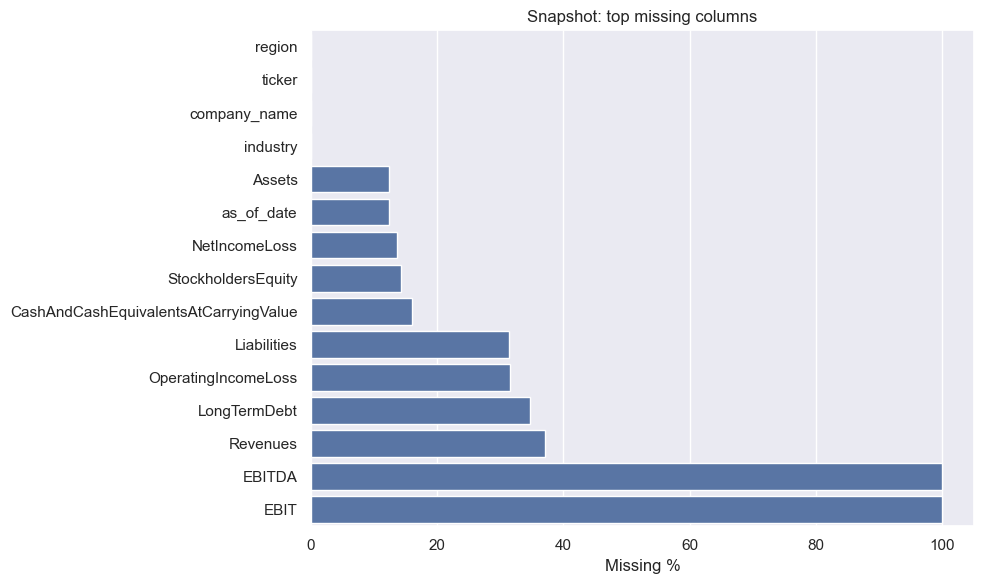

In [17]:
top_missing = snapshot_summary.head(15).sort_values("missing_pct")

plt.figure(figsize=(10, 6))
sns.barplot(x=top_missing["missing_pct"], y=top_missing.index, color="#4C72B0")
plt.title("Snapshot: top missing columns")
plt.xlabel("Missing %")
plt.ylabel("")
plt.tight_layout()
plt.show()


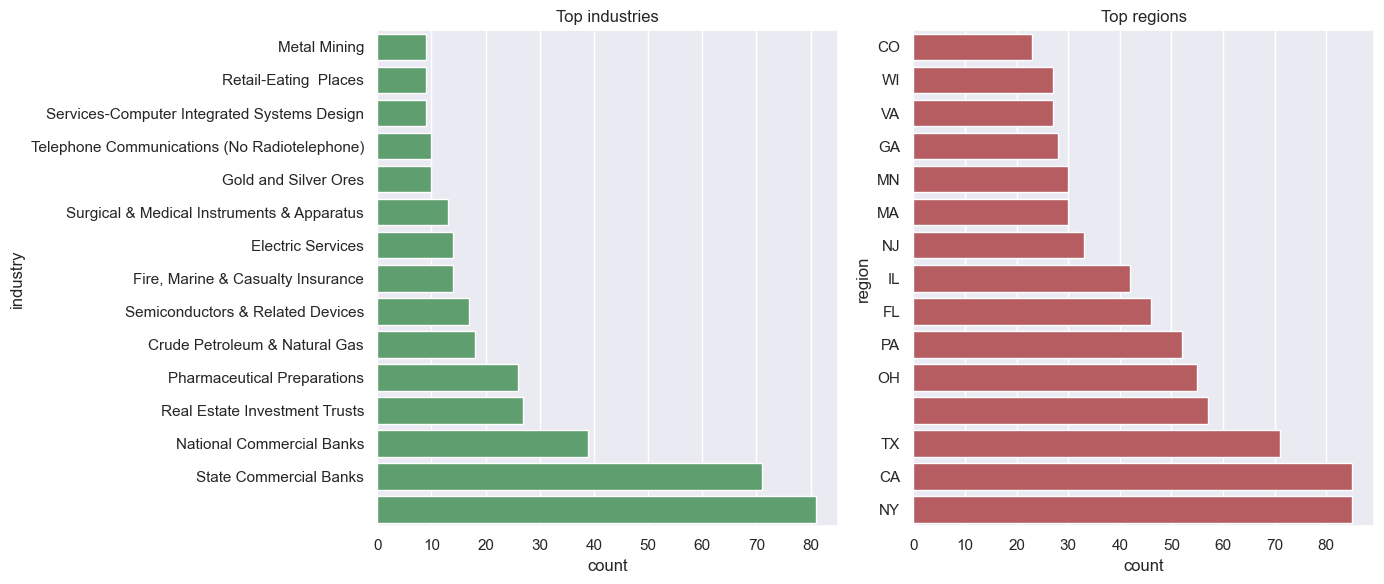

In [18]:
top_industry = (
    financials_df["industry"]
    .fillna("MISSING")
    .astype(str)
    .value_counts()
    .head(15)
    .sort_values()
)
top_region = (
    financials_df["region"]
    .fillna("MISSING")
    .astype(str)
    .value_counts()
    .head(15)
    .sort_values()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(x=top_industry.values, y=top_industry.index, ax=axes[0], color="#55A868")
axes[0].set_title("Top industries")
axes[0].set_xlabel("count")
axes[0].set_ylabel("industry")

sns.barplot(x=top_region.values, y=top_region.index, ax=axes[1], color="#C44E52")
axes[1].set_title("Top regions")
axes[1].set_xlabel("count")
axes[1].set_ylabel("region")

plt.tight_layout()
plt.show()


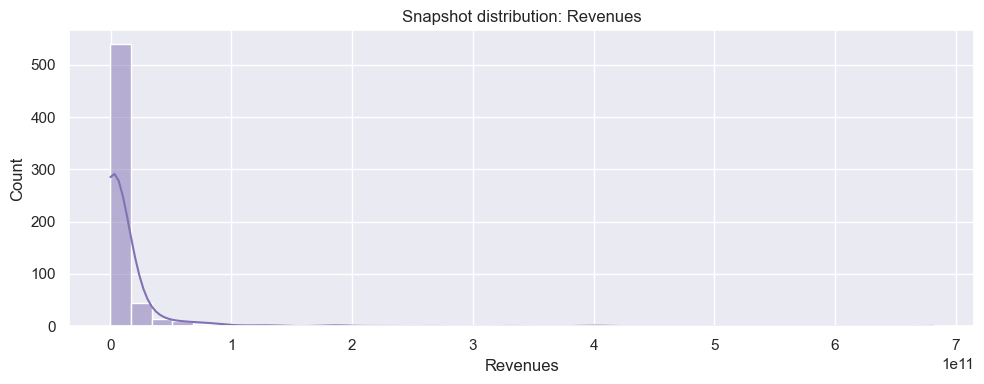

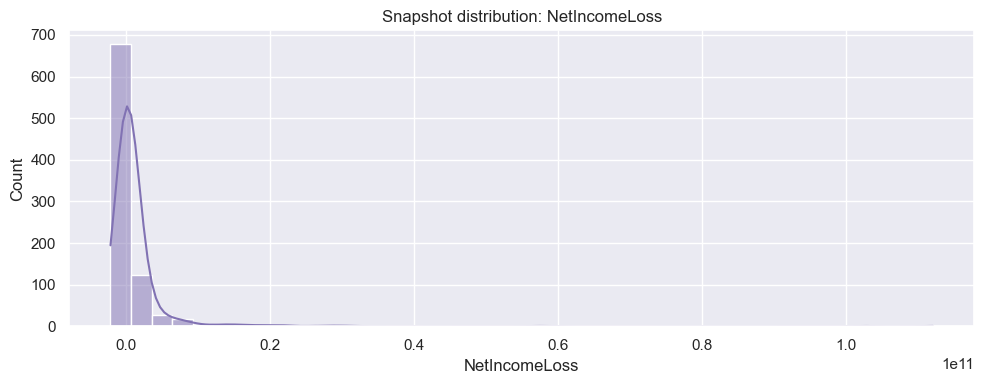

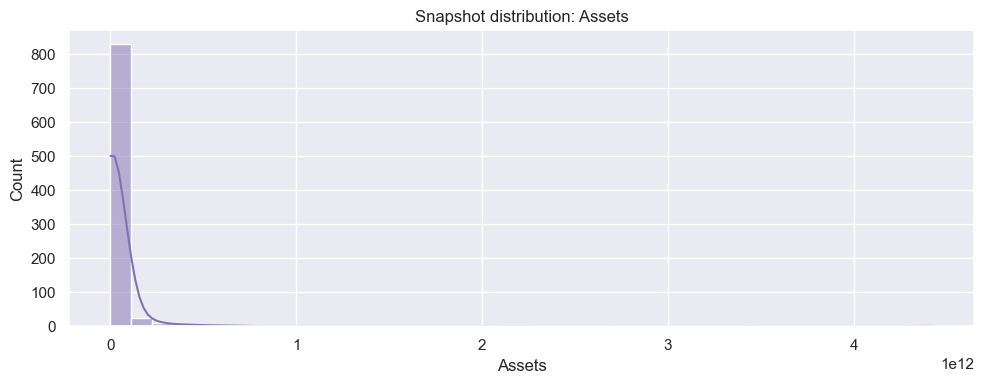

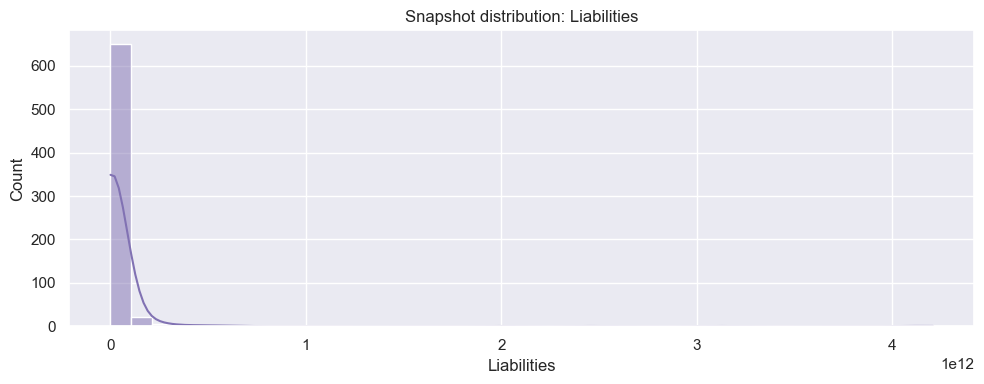

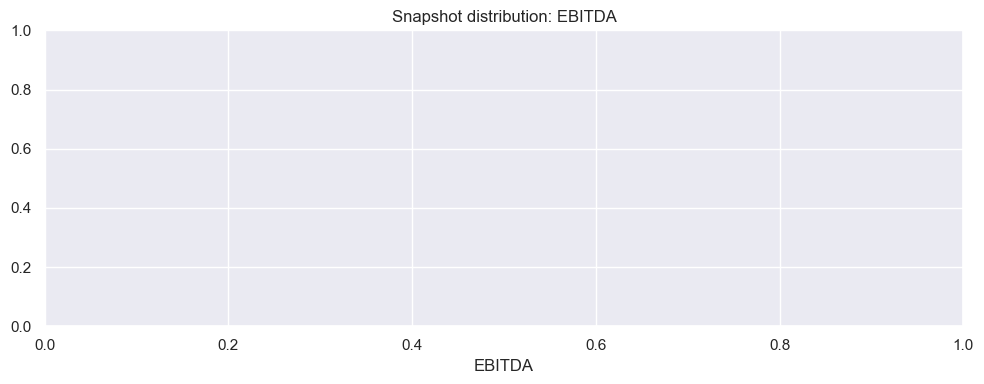

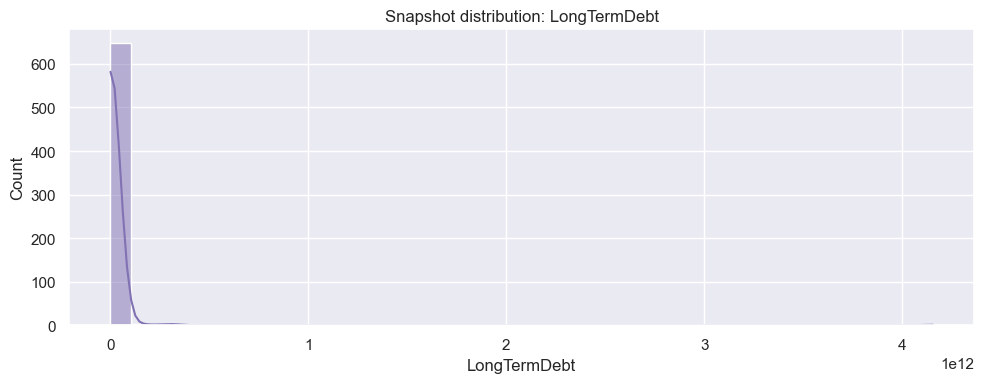

In [19]:
fields = [
    "Revenues",
    "NetIncomeLoss",
    "Assets",
    "Liabilities",
    "EBITDA",
    "LongTermDebt",
]

for col in fields:
    plt.figure(figsize=(10, 4))
    sns.histplot(financials_df[col].dropna(), bins=40, kde=True, color="#8172B3")
    plt.title(f"Snapshot distribution: {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()


## Timeseries: `financials_timeseries.parquet`


In [20]:
timeseries_df["as_of_date"] = pd.to_datetime(timeseries_df["as_of_date"], errors="coerce")

print("shape:", timeseries_df.shape)

timeseries_summary = (
    pd.DataFrame(
        {
            "dtype": timeseries_df.dtypes.astype(str),
            "missing_pct": (timeseries_df.isna().mean() * 100).round(2),
        }
    )
    .sort_values("missing_pct", ascending=False)
)

timeseries_summary.head(20)


shape: (58385, 16)


,dtype,missing_pct
EBIT,float64,100.00
EBITDA,float64,100.00
LongTermDebt,float64,69.42
Revenues,float64,58.02
Liabilities,float64,35.17
OperatingIncomeLoss,float64,28.48
CashAndCashEquivalentsAtCarryingValue,float64,12.63
StockholdersEquity,float64,12.48
NetIncomeLoss,float64,9.05
Assets,float64,8.45


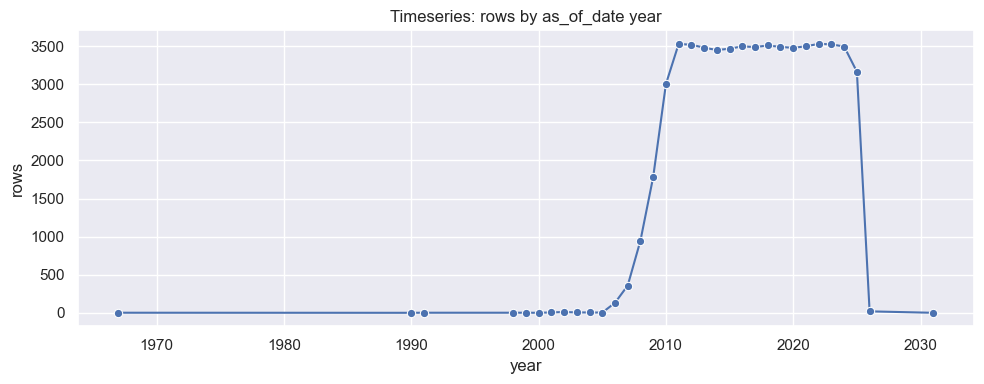

In [21]:
rows_by_year = timeseries_df["as_of_date"].dt.year.value_counts().sort_index()

plt.figure(figsize=(10, 4))
sns.lineplot(x=rows_by_year.index, y=rows_by_year.values, marker="o", color="#4C72B0")
plt.title("Timeseries: rows by as_of_date year")
plt.xlabel("year")
plt.ylabel("rows")
plt.tight_layout()
plt.show()


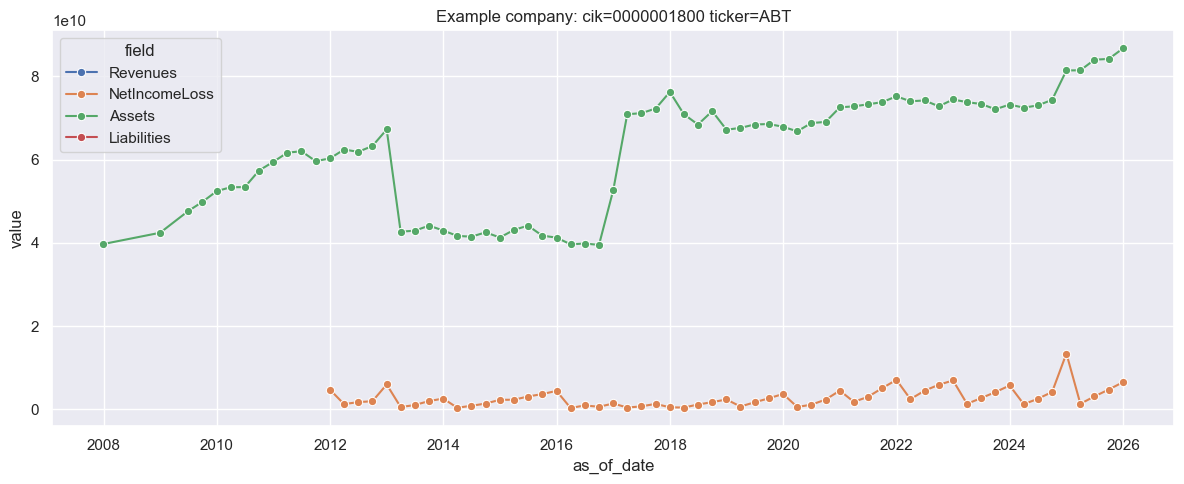

In [22]:
example_cik = timeseries_df["cik"].iloc[0]
company_df = timeseries_df[timeseries_df["cik"] == example_cik].sort_values("as_of_date")
example_ticker = company_df["ticker"].iloc[0]

fields = ["Revenues", "NetIncomeLoss", "Assets", "Liabilities"]
company_long = company_df.melt(
    id_vars=["as_of_date"],
    value_vars=fields,
    var_name="field",
    value_name="value",
)

plt.figure(figsize=(12, 5))
sns.lineplot(data=company_long, x="as_of_date", y="value", hue="field", marker="o")
plt.title(f"Example company: cik={example_cik} ticker={example_ticker}")
plt.xlabel("as_of_date")
plt.ylabel("value")
plt.tight_layout()
plt.show()
